In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib

## Read in data

In [2]:
df = pd.read_csv('data/part_b/part_b_results.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.head()

(3600, 10)


,puzzle_id,strategy,condition,size,word_count,avg_word_length,cells_examined,execution_time,words_found,total_words
0,B_short_0000,Brute Force,short,30,24,5.0,81544,0.029816,24,24
1,B_short_0000,Ordered Search,short,30,24,5.0,89083,0.031675,24,24
2,B_short_0000,Uncommon Letter Search,short,30,24,5.0,2764,0.001639,24,24
3,B_short_0000,Random Sample (attempts=5000),short,30,24,5.0,81544,0.030934,24,24
4,B_short_0000,Patch Search,short,30,24,5.0,81544,0.030332,24,24


In [3]:
df.describe()

,size,word_count,avg_word_length,cells_examined,execution_time,words_found,total_words
count,3600.0,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000
mean,30.0,19.406667,6.296027,46483.582778,0.017996,19.406667,19.406667
std,0.0,2.744093,1.015158,22309.346694,0.008354,2.744093,2.744093
min,30.0,15.000000,5.000000,929.000000,0.000536,15.000000,15.000000
25%,30.0,17.000000,5.000000,41788.000000,0.016305,17.000000,17.000000
50%,30.0,19.000000,6.450000,51526.500000,0.020022,19.000000,19.000000
75%,30.0,22.000000,7.363636,60847.000000,0.023470,22.000000,22.000000
max,30.0,24.000000,7.764706,98016.000000,0.038123,24.000000,24.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   puzzle_id        3600 non-null   str    
 1   strategy         3600 non-null   str    
 2   condition        3600 non-null   str    
 3   size             3600 non-null   int64  
 4   word_count       3600 non-null   int64  
 5   avg_word_length  3600 non-null   float64
 6   cells_examined   3600 non-null   int64  
 7   execution_time   3600 non-null   float64
 8   words_found      3600 non-null   int64  
 9   total_words      3600 non-null   int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 281.4 KB


# Time analysis

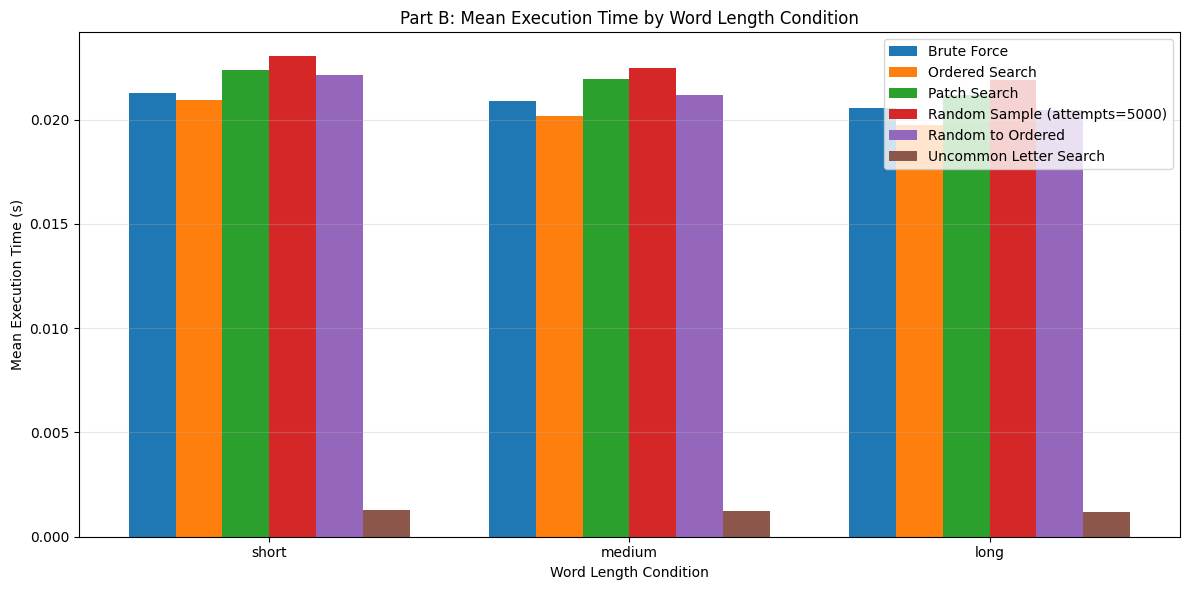

In [5]:
mean_time = df.groupby(['strategy', 'condition'])['execution_time'].mean().reset_index()

# Fix condition order
condition_order = ['short', 'medium', 'long']
mean_time['condition'] = pd.Categorical(mean_time['condition'], categories=condition_order, ordered=True)
mean_time = mean_time.sort_values(['condition', 'strategy'])

fig, ax = plt.subplots(figsize=(12, 6))

strategies = mean_time['strategy'].unique()
x = range(len(condition_order))
width = 0.13
offsets = [i * width - (len(strategies) - 1) * width / 2 for i in range(len(strategies))]

for i, strategy in enumerate(sorted(strategies)):
    group = mean_time[mean_time['strategy'] == strategy]
    group = group.set_index('condition').reindex(condition_order)
    ax.bar([xi + offsets[i] for xi in x], group['execution_time'], width=width, label=strategy)

ax.set_xticks(x)
ax.set_xticklabels(condition_order)
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Mean Execution Time (s)')
ax.set_title('Part B: Mean Execution Time by Word Length Condition')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

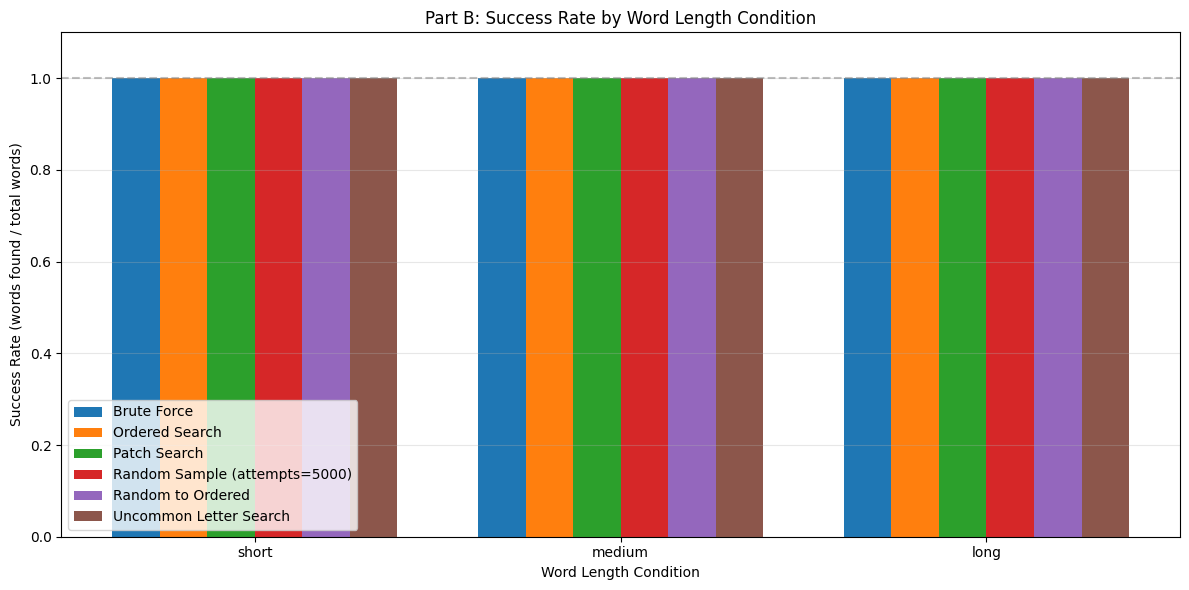

In [6]:
success = df.groupby(['strategy', 'condition']).agg(
    words_found=('words_found', 'mean'),
    total_words=('total_words', 'mean')
).reset_index()
success['success_rate'] = success['words_found'] / success['total_words']

condition_order = ['short', 'medium', 'long']
success['condition'] = pd.Categorical(success['condition'], categories=condition_order, ordered=True)
success = success.sort_values(['condition', 'strategy'])

fig, ax = plt.subplots(figsize=(12, 6))
strategies = sorted(success['strategy'].unique())
x = range(len(condition_order))
width = 0.13
offsets = [i * width - (len(strategies) - 1) * width / 2 for i in range(len(strategies))]

for i, strategy in enumerate(strategies):
    group = success[success['strategy'] == strategy].set_index('condition').reindex(condition_order)
    ax.bar([xi + offsets[i] for xi in x], group['success_rate'], width=width, label=strategy)

ax.set_xticks(x)
ax.set_xticklabels(condition_order)
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Success Rate (words found / total words)')
ax.set_title('Part B: Success Rate by Word Length Condition')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

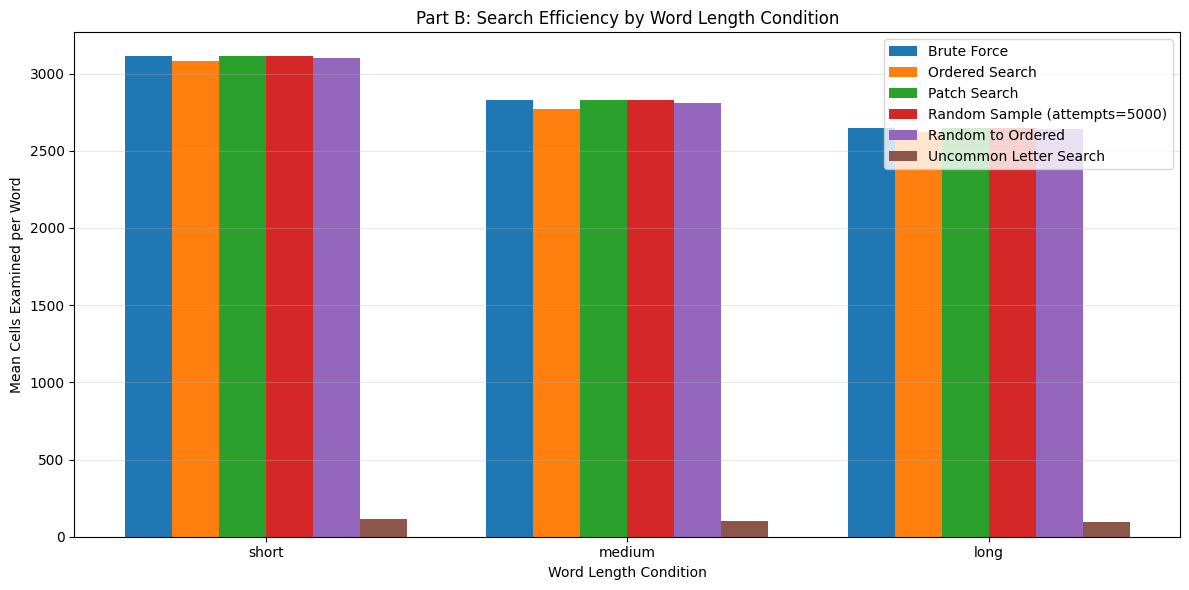

In [7]:
eff = df.groupby(['strategy', 'condition']).agg(
    cells_examined=('cells_examined', 'mean'),
    total_words=('total_words', 'mean')
).reset_index()
eff['cells_per_word'] = eff['cells_examined'] / eff['total_words']
eff['condition'] = pd.Categorical(eff['condition'], categories=condition_order, ordered=True)
eff = eff.sort_values(['condition', 'strategy'])

fig, ax = plt.subplots(figsize=(12, 6))
for i, strategy in enumerate(strategies):
    group = eff[eff['strategy'] == strategy].set_index('condition').reindex(condition_order)
    ax.bar([xi + offsets[i] for xi in x], group['cells_per_word'], width=width, label=strategy)

ax.set_xticks(x)
ax.set_xticklabels(condition_order)
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Mean Cells Examined per Word')
ax.set_title('Part B: Search Efficiency by Word Length Condition')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

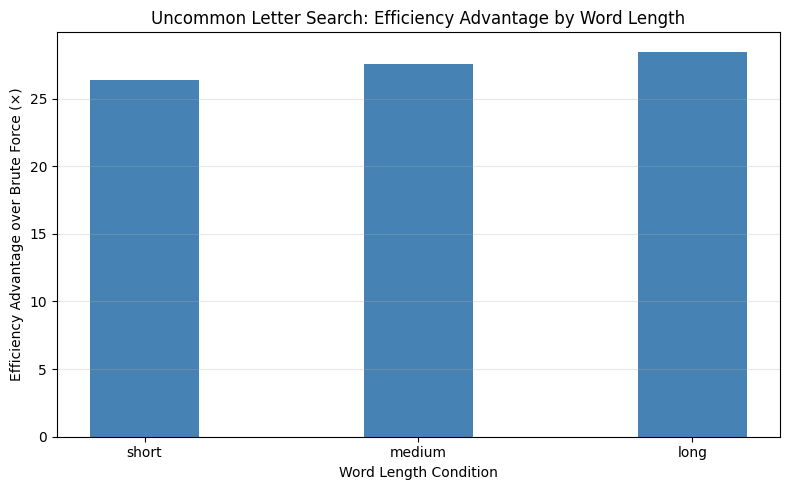

In [8]:
eff_uls = eff.copy()
bf_cells = eff_uls[eff_uls['strategy'] == 'Brute Force'][['condition', 'cells_per_word']].rename(columns={'cells_per_word': 'bf_cells'})
eff_uls = eff_uls.merge(bf_cells, on='condition')
eff_uls['advantage_ratio'] = eff_uls['bf_cells'] / eff_uls['cells_per_word']
eff_uls = eff_uls[eff_uls['strategy'] == 'Uncommon Letter Search'].set_index('condition').reindex(condition_order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(condition_order, eff_uls['advantage_ratio'], color='steelblue', width=0.4)
ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Efficiency Advantage over Brute Force (×)')
ax.set_title('Uncommon Letter Search: Efficiency Advantage by Word Length')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Generate Formatted plots for report

In [10]:
# ── IEEE formatting ──────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'lines.linewidth':   1.8,
    'lines.markersize':  4,
    'axes.linewidth':    0.8,
    'grid.linewidth':    0.5,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    # 'text.usetex':     True,   # uncomment if LaTeX is installed
})

IEEE_1COL = 3.5    # single-column width (inches)
IEEE_2COL = 7.16   # full-width (both columns)

# Wong (2011) colorblind-safe palette
COLORS = {
    'Brute Force':                   '#000000',
    'Ordered Search':                '#0072B2',
    'Patch Search':                  '#009E73',
    'Random Sample (attempts=5000)': '#D55E00',
    'Random to Ordered':             '#CC79A7',
    'Uncommon Letter Search':        '#E69F00',
}
MARKERS = {
    'Brute Force':                   'o',
    'Ordered Search':                's',
    'Patch Search':                  '^',
    'Random Sample (attempts=5000)': 'D',
    'Random to Ordered':             'v',
    'Uncommon Letter Search':        '*',
}

os.makedirs('plots', exist_ok=True)

In [11]:
strategies_sorted = sorted(COLORS.keys())

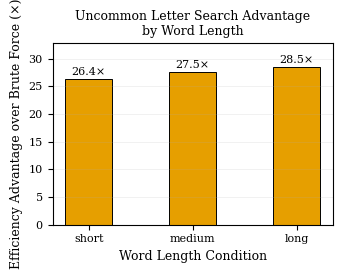

Saved fig3_uls_word_length.pdf


In [13]:
condition_order = ['short', 'medium', 'long']
eff_b = df.groupby(['strategy', 'condition']).agg(
    cells_examined=('cells_examined', 'mean'),
    total_words=('total_words', 'mean')
).reset_index()
eff_b['cells_per_word'] = eff_b['cells_examined'] / eff_b['total_words']

bf_b = eff_b[eff_b['strategy'] == 'Brute Force'][['condition', 'cells_per_word']].rename(columns={'cells_per_word': 'bf_cells'})
eff_b = eff_b.merge(bf_b, on='condition')
eff_b['advantage'] = eff_b['bf_cells'] / eff_b['cells_per_word']
uls = eff_b[eff_b['strategy'] == 'Uncommon Letter Search'].set_index('condition').reindex(condition_order)

fig, ax = plt.subplots(figsize=(IEEE_1COL, 2.8))
bars = ax.bar(condition_order, uls['advantage'],
              color=COLORS['Uncommon Letter Search'], width=0.45, edgecolor='black', linewidth=0.7)

# value labels on bars
for bar, val in zip(bars, uls['advantage']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}×', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Word Length Condition')
ax.set_ylabel('Efficiency Advantage over Brute Force (×)')
ax.set_title('Uncommon Letter Search Advantage\nby Word Length')
ax.set_ylim(0, uls['advantage'].max() * 1.15)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('plots/fig3_uls_word_length.pdf')
plt.show()
print("Saved fig3_uls_word_length.pdf")